In [1]:
# Import libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# --
list_params = ['outTempMax', 'outTempMin', 'avg_windSpeed', 'avg_windDir', 'total_rain', 'dateTime']

df_eda = pd.read_csv('data/data_meteo_eda_2326.csv')[list_params]
df_eda['dateTime'] = pd.to_datetime(df_eda['dateTime'])

# --
df_eda.head()

,outTempMax,outTempMin,avg_windSpeed,avg_windDir,total_rain,dateTime
0,29.9,14.3,2,131.423907,5.8,2023-01-01 03:00:00+00:00
1,30.6,10.2,2,168.660072,0.0,2023-01-02 03:00:00+00:00
2,29.9,11.7,1,153.128990,0.7,2023-01-03 03:00:00+00:00
3,31.4,13.5,2,150.192348,0.0,2023-01-04 03:00:00+00:00
4,33.5,12.2,2,190.833822,0.0,2023-01-05 03:00:00+00:00


In [3]:
def rem_outl_std(x, times=2):
    x_median = np.nanmedian(x)
    x_std = np.nanstd(x)
    
    return np.where(((x < x_median-times*x_std) | (x > x_median+times*x_std)), np.nan, x)

def rem_outl_perc(x, lower=1, upper=99):
    x_lower = np.nanpercentile(x, lower)
    x_upper = np.nanpercentile(x, upper)
    return np.where(((x < x_lower) | (x > x_upper)), np.nan, x)

def nanmedian_two(array_1, array_2):
    """Median of two arrays combined, ignoring NaNs.

    The arrays can have different shapes; both are flattened and joined.
    Returns NaN if every value is NaN.
    """
    stack = np.stack([array_1, array_2], axis=0)
    #print(stack.shape)
    return np.nanmedian(stack, axis=0)

In [4]:
# --
medn_eda = nanmedian_two(rem_outl_std(np.array(df_eda['outTempMax'])), 
              rem_outl_std(np.array(df_eda['outTempMin'])))

/tmp/ipykernel_5804/1313232234.py:20: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(stack, axis=0)


/tmp/ipykernel_5487/3974219981.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='best')
/tmp/ipykernel_5487/3974219981.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(loc='best')


Text(0.5, 1.0, 'E. D. Alighieri-PP Acumulada')

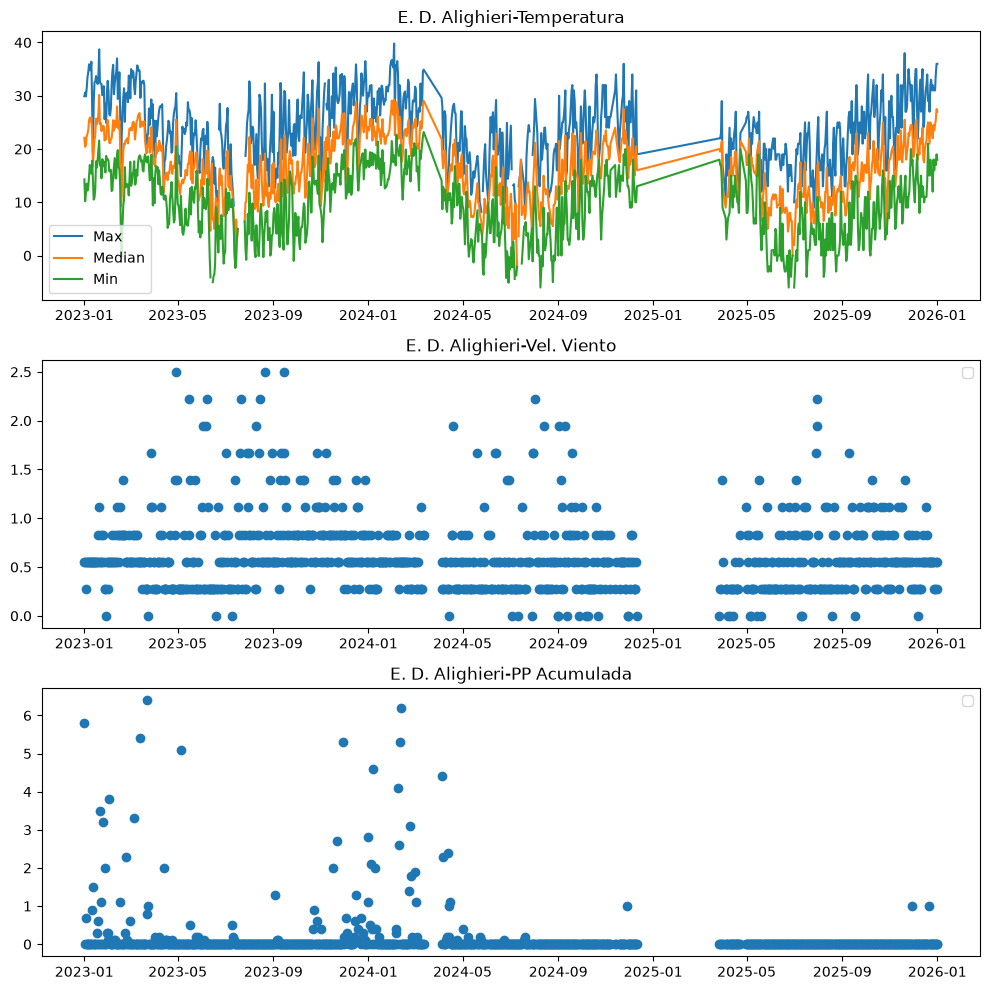

In [101]:
#fig, ax = plt.subplots(2, 1, figsize=(10, 8))
fig, ax = plt.subplots(3, 1, figsize=(10, 10), tight_layout=True)

# --
ax[0].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['outTempMax'])), label='Max')
ax[0].plot(df_eda['dateTime'], medn_eda, label='Median')
ax[0].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['outTempMin'])), label='Min')

ax[0].legend(loc='best')
ax[0].set_title('E. D. Alighieri-Temperatura')

# --
ax[1].plot(df_eda['dateTime'], np.array(df_eda['avg_windSpeed'])*0.277778, marker='o', linestyle='none', label='')

ax[1].legend(loc='best')
ax[1].set_title('E. D. Alighieri-Vel. Viento')


# --
ax[2].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['total_rain'])), marker='o', linestyle='none', label='')

ax[2].legend(loc='best')
ax[2].set_title('E. D. Alighieri-PP Acumulada')


## Temperature data

### Explore ERA5 data

In [20]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_tp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-2m-temperatureomkgyya2.nc')

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

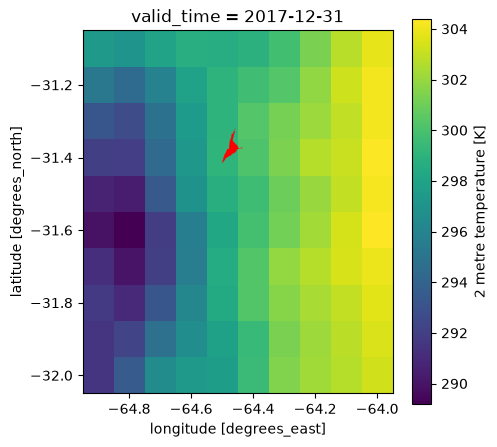

In [21]:
# --
fig, ax = plt.subplots(figsize=(5, 5))
ds_tp.isel(valid_time=0).t2m.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [22]:
# --
ds_tp = ds_tp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tp = ds_tp.rio.write_crs("EPSG:4326", inplace=False)

# --
ds_tp_clip = ds_tp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

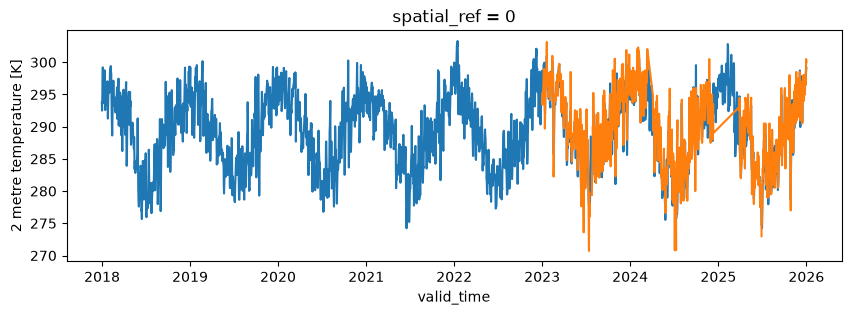

In [23]:
# --
fig, ax = plt.subplots(figsize=(10, 3))
spatial_mean = ds_tp_clip.mean(dim=['latitude', 'longitude'])
spatial_mean['t2m'].resample(valid_time='1D').mean().plot(ax=ax)
ax.plot(df_eda['dateTime'], medn_eda+273, label='Median')

### Fill gap with era5

In [24]:
# --
tera5 = ds_tp_clip.mean(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
tera5 = tera5.sel(valid_time=slice('2023-01-01', '2026-01-01'))
tera5_val = tera5.t2m.values
tera5_time = tera5.valid_time.values

# --
tmedn_eda = nanmedian_two(rem_outl_std(np.array(df_eda['outTempMax'])), 
              rem_outl_std(np.array(df_eda['outTempMin'])))
t_eda = tmedn_eda + 273

/tmp/ipykernel_5804/1313232234.py:20: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(stack, axis=0)


In [58]:
# --
arrayt_tera5 = tera5_time.astype('datetime64[D]')
arrayt_teda = np.array(df_eda['dateTime']).astype('datetime64[D]')

# --
t_eda_fill = []

for et in arrayt_tera5:

    match_idx = np.where(arrayt_teda == et)[0]

    if len(match_idx) > 0:
        t_eda_fill.append(t_eda[match_idx[0]])
    else:
        t_eda_fill.append(np.nan)

tmedn_eda_fill_array = np.array(t_eda_fill)

/tmp/ipykernel_5804/1365123735.py:3: UserWarning: no explicit representation of timezones available for np.datetime64
  arrayt_teda = np.array(df_eda['dateTime']).astype('datetime64[D]')


In [59]:
# --
tera5_mknan = tera5_val[~np.isnan(tmedn_eda_fill_array)]
tmedn_eda_fill_array_mknan = tmedn_eda_fill_array[~np.isnan(tmedn_eda_fill_array)]

# --
r, p = pearsonr(tera5_mknan, tmedn_eda_fill_array_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.952, p = 0.0000


Text(0, 0.5, 'EDA data')

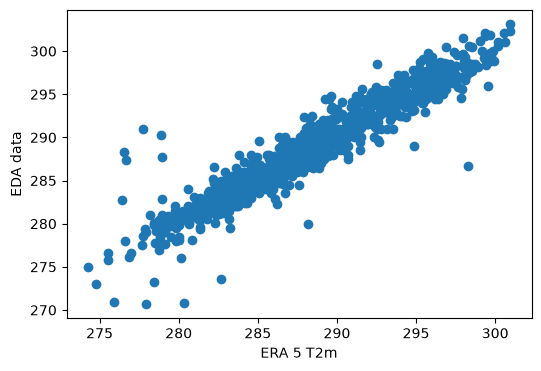

In [60]:
# --
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(tera5_mknan, tmedn_eda_fill_array_mknan,)

ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')

In [61]:
# --
X = tera5_mknan.reshape(-1, 1)
y = tmedn_eda_fill_array_mknan.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.941


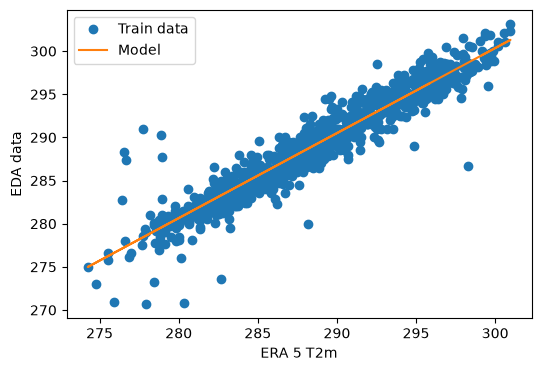

In [62]:
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(tera5_mknan, tmedn_eda_fill_array_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(tera5_mknan, model.predict(tera5_mknan.reshape(-1, 1)).reshape(-1), label='Model')

# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [63]:
tmedn_eda_fill_model = []

for i, et in enumerate(arrayt_tera5):
    if et in arrayt_teda:
        t_index = list(arrayt_teda).index(et)
        val = t_eda[t_index]
    else:
        val = np.nan

    if np.isnan(val):
        # date missing OR in-situ value at that date is NaN -> use the model
        pred = model.predict(np.array(tera5_val[i]).reshape(-1, 1))
        val = pred[0][0]  # use pred[0][0] instead if predict returns a 2D array
        #print(val)

    tmedn_eda_fill_model.append(val)

tmedn_eda_full = np.array(tmedn_eda_fill_model)

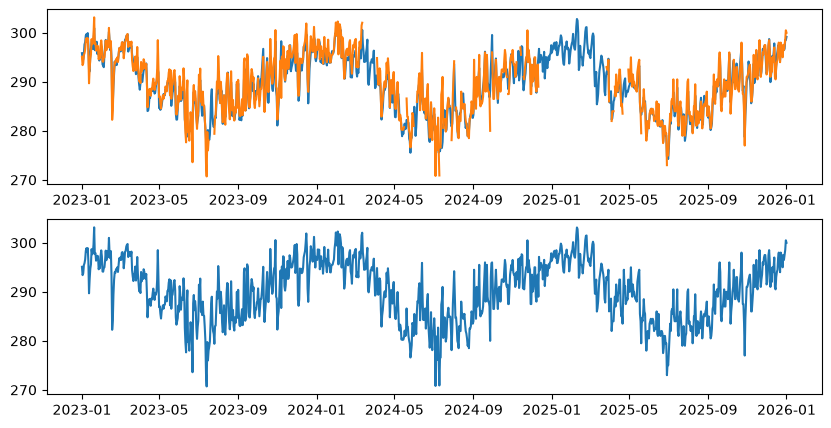

In [64]:
# --
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()

ax[0].plot(tera5_time, tera5_val)
ax[0].plot(tera5_time, tmedn_eda_fill_array, label='Median')

ax[1].plot(tera5_time, tmedn_eda_full, label='Median')

###  Summary

In [65]:
# --
time_values_norm_2326 = arrayt_tera5
tp_values_era5_2326 = tera5_val
tp_values_eda_2326 = tmedn_eda_full

# --
print(time_values_norm_2326.shape, tp_values_era5_2326.shape, tp_values_eda_2326.shape)

(1097,) (1097,) (1097,)


## Precipitation data

### Explore ERA5 data

In [27]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_tp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-pressure-precipitationmqdk43fk.nc')

<Axes: title={'center': 'valid_time = 2018-01-08T08:00:00'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

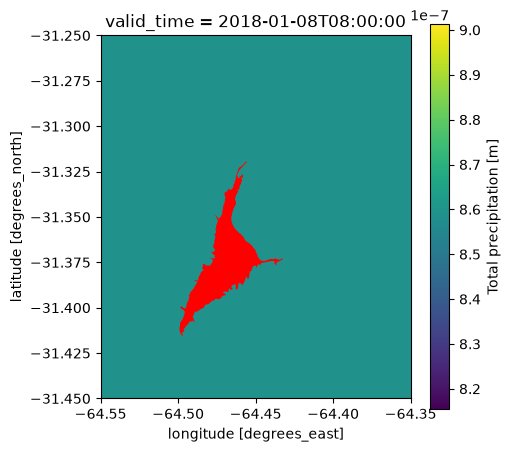

In [28]:
# --
fig, ax = plt.subplots(figsize=(5, 5))

# --
ds_tp.isel(valid_time=200).sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).tp.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [29]:
# --
ds_tp = ds_tp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tp = ds_tp.rio.write_crs("EPSG:4326", inplace=False)

# --
ds_tp_clip = ds_tp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

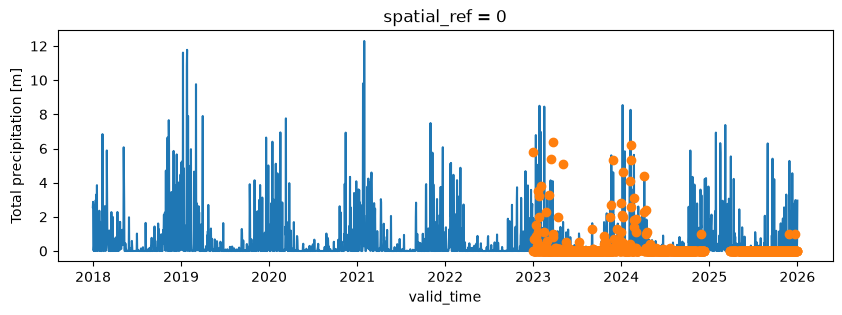

In [30]:
fig, ax = plt.subplots(figsize=(10, 3))

# --
spatial_mean = ds_tp_clip.sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).mean(dim=['latitude', 'longitude'])
total_daily = spatial_mean.resample(valid_time="1D").max() * 1000
total_daily.tp.plot(ax=ax)

# --
ax.plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['total_rain'])), marker='o', linestyle='none', label='')


### Fill gaps

In [31]:
# --
pera5 = total_daily # Recycle previous processing
pera5 = pera5.sel(valid_time=slice('2023-01-01', '2026-01-01'))
pera5_val = pera5.tp.values
pera5_time = pera5.valid_time.values

# --
p_eda = rem_outl_std(np.array(df_eda['total_rain']))

In [32]:
# --
arrayt_pera5 = pera5_time.astype('datetime64[D]')
arrayt_peda = np.array(df_eda['dateTime']).astype('datetime64[D]')

# --
p_eda_fill = []

for et in arrayt_pera5:

    match_idx = np.where(arrayt_peda == et)[0]

    if len(match_idx) > 0:
        p_eda_fill.append(p_eda[match_idx[0]])
    else:
        p_eda_fill.append(np.nan)

p_eda_fill_array = np.array(p_eda_fill)

/tmp/ipykernel_5804/1067703849.py:3: UserWarning: no explicit representation of timezones available for np.datetime64
  arrayt_peda = np.array(df_eda['dateTime']).astype('datetime64[D]')


In [33]:
# --
pera5_mknan = pera5_val[~np.isnan(p_eda_fill_array)]
p_eda_fill_array_mknan = p_eda_fill_array[~np.isnan(p_eda_fill_array)]

# --
r, p = pearsonr(pera5_mknan, p_eda_fill_array_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.499, p = 0.0000


Text(0, 0.5, 'EDA data')

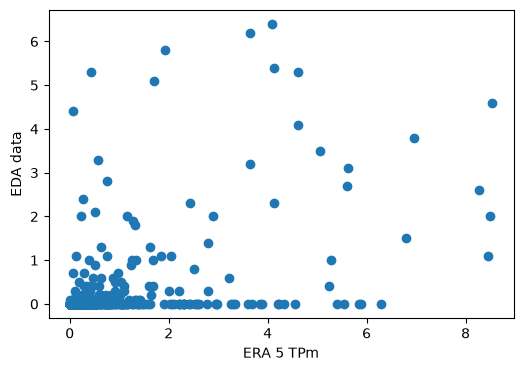

In [34]:
# --
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(pera5_mknan, p_eda_fill_array_mknan)

ax.set_xlabel('ERA 5 TPm')
ax.set_ylabel('EDA data')

Conclusión: Por $R^{2}$ bajo, no se llena el gap con ERA5

### Summary

In [35]:
# --
time_values_norm_2326 = arrayt_pera5
p_values_era5_2326 = pera5_val

# --
print(time_values_norm_2326.shape, p_values_era5_2326.shape)

(1097,) (1097,)


## Wind data

In [36]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_w = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-wind529wrpgo.nc')

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

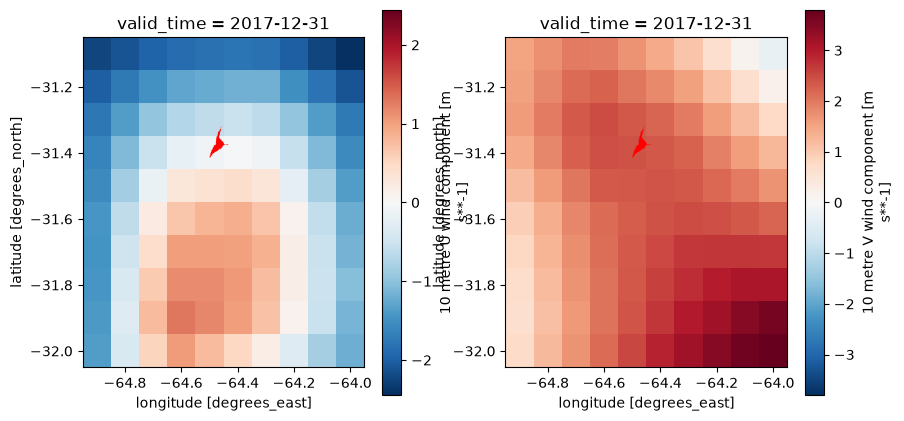

In [37]:
# --
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.flatten()

# --
ds_w.isel(valid_time=0).u10.plot(ax=ax[0])
esr_vector.dissolve().plot(ax=ax[0], color='red')

# --
ds_w.isel(valid_time=0).v10.plot(ax=ax[1])
esr_vector.dissolve().plot(ax=ax[1], color='red')

In [38]:
# --
vel_mag = xr.ufuncs.sqrt(ds_w.u10**2+ds_w.v10**2)

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

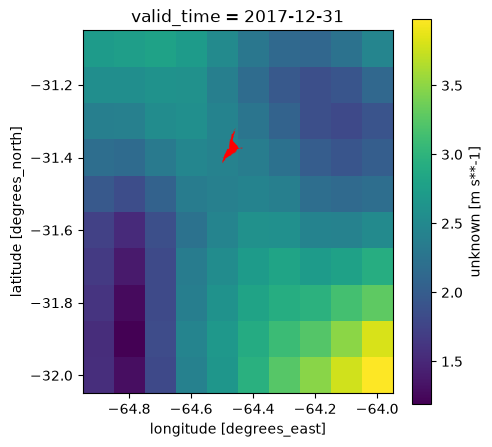

In [39]:
# --
fig, ax = plt.subplots(figsize=(5, 5))

# --
vel_mag.isel(valid_time=0).plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [40]:
# --
da_w = vel_mag.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
da_w = da_w.rio.write_crs("EPSG:4326", inplace=False)

# --
da_w_clip = da_w.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

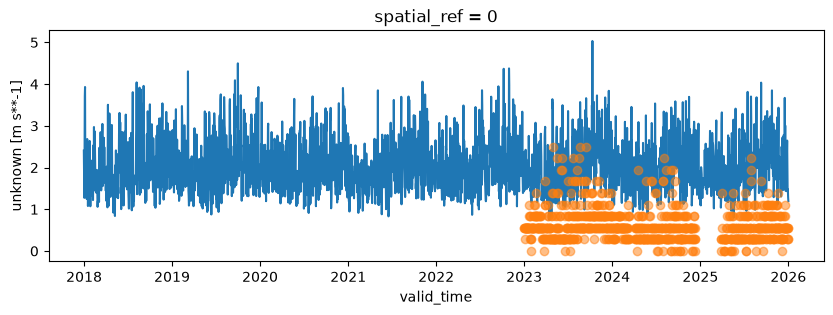

In [41]:
# --
fig, ax = plt.subplots(figsize=(10, 3))

spatial_mean = da_w_clip.mean(dim=['latitude', 'longitude'])
(spatial_mean.resample(valid_time='1D').mean()).plot(ax=ax)

ax.plot(df_eda['dateTime'], np.array(df_eda['avg_windSpeed'])*0.277778,
        marker='o', linestyle='none',
        alpha=0.5, label='')

**Fill gaps**

In [42]:
# --
wera5 = da_w_clip.mean(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
wera5 = wera5.sel(valid_time=slice('2023-01-01', '2026-01-01'))
wera5_val = wera5.values
wera5_time = wera5.valid_time.values

# --
w_eda = np.array(df_eda['avg_windSpeed'])*0.277778

In [43]:
# --
arrayt_wera5 = wera5_time.astype('datetime64[D]')
arrayt_weda = np.array(df_eda['dateTime']).astype('datetime64[D]')

# --
w_eda_fill = []

for et in arrayt_wera5:

    match_idx = np.where(arrayt_weda == et)[0]

    if len(match_idx) > 0:
        w_eda_fill.append(w_eda[match_idx[0]])
    else:
        w_eda_fill.append(np.nan)

w_eda_fill_array = np.array(w_eda_fill)

/tmp/ipykernel_5804/2997543277.py:3: UserWarning: no explicit representation of timezones available for np.datetime64
  arrayt_weda = np.array(df_eda['dateTime']).astype('datetime64[D]')


In [44]:
# --
wera5_mknan = wera5_val[~np.isnan(w_eda_fill_array)]
w_eda_fill_array_mknan = w_eda_fill_array[~np.isnan(w_eda_fill_array)]

# --
r, p = pearsonr(wera5_mknan, w_eda_fill_array_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.639, p = 0.0000


Text(0, 0.5, 'EDA data')

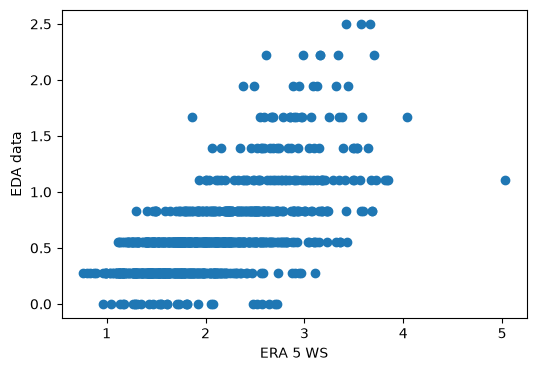

In [45]:
# --
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(wera5_mknan, w_eda_fill_array_mknan)

ax.set_xlabel('ERA 5 WS')
ax.set_ylabel('EDA data')

In [46]:
# --
X = wera5_mknan.reshape(-1, 1)
y = w_eda_fill_array_mknan.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.400


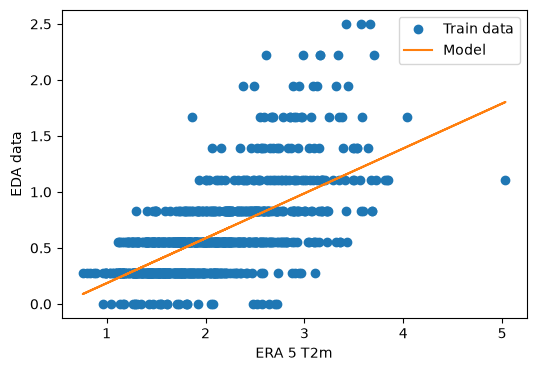

In [47]:
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(wera5_mknan, w_eda_fill_array_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(wera5_mknan, model.predict(wera5_mknan.reshape(-1, 1)).reshape(-1), label='Model')

# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [48]:
# --
w_eda_fill_model = []

for i, et in enumerate(arrayt_wera5):
    if et in arrayt_weda:
        t_index = list(arrayt_weda).index(et)
        val = w_eda[t_index]
    else:
        val = np.nan

    if np.isnan(val):
        # date missing OR in-situ value at that date is NaN -> use the model
        pred = model.predict(np.array(wera5_val[i]).reshape(-1, 1))
        val = pred[0][0]  # use pred[0][0] instead if predict returns a 2D array
        #print(val)

    w_eda_fill_model.append(val)

w_eda_full = np.array(w_eda_fill_model)

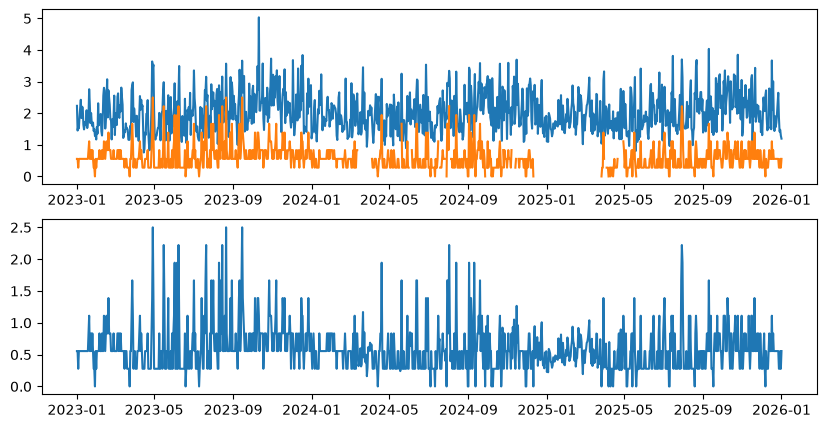

In [49]:
# --
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()

ax[0].plot(wera5_time, wera5_val)
ax[0].plot(wera5_time, w_eda_fill_array, label='Median')

ax[1].plot(wera5_time, w_eda_full, label='Median')

### Summary

In [50]:
# --
time_values_norm_2326 = arrayt_wera5
w_values_era5_2326 = wera5_val
w_values_eda_2326 = w_eda_full

# --
print(time_values_norm_2326.shape, w_values_era5_2326.shape, w_values_eda_2326.shape)

(1097,) (1097,) (1097,)


## Merga all data

In [66]:
# --
df_merged = pd.DataFrame()

# --
df_merged['yy-mm-dd'] = time_values_norm_2326
df_merged['TP-ERA5_K'] = tera5_val
df_merged['TP-EDA_K'] = tmedn_eda_full

# --
df_merged['PP-ERA5_mm'] = pera5_val

# --
df_merged['WM-ERA5_ms'] = wera5_val
df_merged['WD-EDA_ms'] = w_eda_full

In [70]:
# --
df_merged.head(10)

,yy-mm-dd,TP-ERA5_K,TP-EDA_K,PP-ERA5_mm,WM-ERA5_ms,WD-EDA_ms
0,2023-01-01,295.842529,295.10,1.931096,2.234002,0.555556
1,2023-01-02,294.624695,293.40,0.243276,1.452583,0.555556
2,2023-01-03,294.546143,293.80,0.975191,1.596819,0.277778
3,2023-01-04,295.643951,295.45,0.001694,1.522040,0.555556
4,2023-01-05,297.624725,295.85,0.000855,1.896282,0.555556
5,2023-01-06,298.085693,296.60,0.000435,2.140706,0.555556
6,2023-01-07,299.432892,298.35,0.253059,2.425521,0.555556
7,2023-01-08,299.732697,298.90,0.173748,1.847322,0.555556
8,2023-01-09,298.900238,298.15,0.129978,2.207697,0.555556
9,2023-01-10,299.938385,298.90,0.540997,2.174129,0.555556


In [71]:
# --
df_merged.to_csv('output/meteo_merged_2326.csv', index=False)